In [ ]:
#Libraries for data and analysis handling
import pandas as pd #For data manipulation and preprocessing
import numpy as np #For numerical computations and array handling


In [ ]:
#Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Libraries for implementation of SVR and Random forest models (ML)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression

from sklearn.svm import SVR
from sklearn.impute import SimpleImputer

In [ ]:
#Libraries building LSTM for prediction
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler #!!


In [ ]:
from google.colab import files
uploaded= files.upload()
df = pd.read_excel('/content/traffic_data_2025.xlsx') #Dataset download
#uploaded= files.upload()
#weather= pd.read_csv("SF_weather_data.csv") #Weather data

In [ ]:
df.head() #print the first 5 rows


 أسماء الأعمدة

In [ ]:
print(df.columns) #print col names


In [ ]:
df_subset = df[['Flow', 'Occupancy', 'Speed']]


In [ ]:
df['Date/Time']= pd.to_datetime(df['Date/Time']) #convert time column to date and time format
df= df.sort_values(by='Date/Time') #arrange values according to time
print(df['Date/Time'].head())

In [ ]:
#creat new timeline features
df['hour']= df['Date/Time'].dt.hour
df['day_of_week']= df['Date/Time'].dt.day_of_week
df['month']= df['Date/Time'].dt.month
df['is_weekend']= (df['day_of_week'] >= 5).astype(int)

تحويل السرعه km/h

In [ ]:
# Convert Speed from miles per hour (mph) to kilometers per hour (km/h)
df_subset.loc[:, 'Speed'] = df_subset['Speed'] * 1.60934


In [ ]:
df_subset.head()


In [ ]:
#df_subset.isnull().sum()


In [ ]:
df_subset.isnull()


In [ ]:
print("Before mean")
print(df_subset.isnull().sum())



In [ ]:
# Fill missing numeric values with the column mean
df_subset = df_subset.fillna(df_subset.mean(numeric_only=True))

# Replace zeros in 'Occupancy' and 'Speed' with the mean of non-zero values
df_subset['Occupancy'] = df_subset['Occupancy'].replace(0, df_subset[df_subset['Occupancy'] != 0]['Occupancy'].mean())
df_subset['Speed'] = df_subset['Speed'].replace(0, df_subset[df_subset['Speed'] != 0]['Speed'].mean())  #fill missing values with column mean (numeric colmns only)
print("Data after filling missing values with the mean:")
print(df_subset )


In [ ]:
print(df_subset.isna().sum())

In [ ]:
df_subset.info()

In [ ]:
#encoding
#Check for object/categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", cat_cols)


In [ ]:
#encode categorical features if it exists
if len(cat_cols) > 0:
    print("\nCategorical columns to encode:", cat_cols.tolist())
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])
else:
    print("\nNo categorical columns found.")


In [ ]:

# Define input features and target variable
X= df_subset[['Flow', 'Speed']]
y = df_subset['Occupancy']  #target

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of training and testing sets
X_train.shape, X_test.shape

In [ ]:
print(X.columns)

In [ ]:
print(X_train.isna().sum())
print(X_test.isna().sum())



In [ ]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns= X_train.columns, index= X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns= X_test.columns, index= X_test.index)

SVR

# **RBF**

In [ ]:
# Select features (Flow, Speed)
X_train_sub = X_train_scaled[['Flow', 'Speed']]
X_test_sub  = X_test_scaled[['Flow', 'Speed']]


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Build SVR model (RBF kernel)
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train_sub, y_train)
# Predictions
y_pred_rbf = svr_rbf.predict(X_test_sub)
# Evaluation
rmse = np.sqrt(mean_squared_error(y_test,  y_pred_rbf))
mae_rbf = mean_absolute_error(y_test, y_pred_rbf)
r2_rbf = r2_score(y_test, y_pred_rbf)
print("**RBF kernel SVR result**")
print(f"RMSE= {rmse: .4f}")
print(f"MAE= {mae_rbf: .4f}")
print(f"R2= {r2_rbf: .4f}")

In [ ]:
plt.scatter(y_test.values, y_pred_rbf, color='red', alpha=0.5, label='original data')
plt.plot([y_test.values.min(), y_test.values.max()],
         [y_test.values.min(), y_test.values.max()], color='blue')
plt.title('SVR with RBF Kernel')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()
plt.show()


**Linear Kernel**


In [ ]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Build SVR model (Linear kernel )
lin_reg = LinearRegression()
lin_reg.fit(X_train_sub, y_train)
# Predictions
y_pred_lin = lin_reg.predict(X_test_sub)
# Evaluation
rmse_lin = np.sqrt(mean_squared_error(y_test,  y_pred_lin))
mae_lin = mean_absolute_error(y_test, y_pred_rbf)
r2_lin = r2_score(y_test, y_pred_rbf)
print("Linear Regression results")
print(f"RMSE = {rmse_lin:.4f}")
print(f"MAE = {mae_lin:.4f}")
print(f"R2  = {r2_lin:.4f}")

In [ ]:
# Visualization
plt.scatter(y_test, y_pred_lin, color='green', alpha=0.5, label='original data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue')
plt.title('Linear Regression Prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()
plt.show()


 Kernel Polynomial

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
"""#نختار فقط الاعمده اللي بنستخدمها للتنبؤ
X_train_sub= X_train[['Flow', 'Speed']]
X_test_sub= X_test[['Flow', 'Speed']]
#نحول العمود الى صف واحد مناسب للمودل
y_train_ravel= y_train.values.ravel()
y_test_ravel= y_test.values.ravel()"""


In [ ]:
# Build SVR model (Polynomial  kernel)
svr_poly= SVR(kernel='poly')
svr_poly.fit(X_train_sub, y_train)
# Predictions
y_pred_poly= svr_poly.predict(X_test_sub)
# Evaluation
rmse_poly = np.sqrt(mean_squared_error(y_test,  y_pred_poly))
mae_poly= mean_absolute_error(y_test, y_pred_poly)
r2_poly= r2_score(y_test, y_pred_poly)

print("**Polynomial kernel result**")
print(f"RMSE= {rmse_poly: .4f}")
print(f"MAE= {mae_poly: .4f}")
print(f"R2= {r2_poly: .4f}")

**Polynomial kernel result**
RMSE=  4020.3979
MAE=  3356.2118
R2=  0.0468


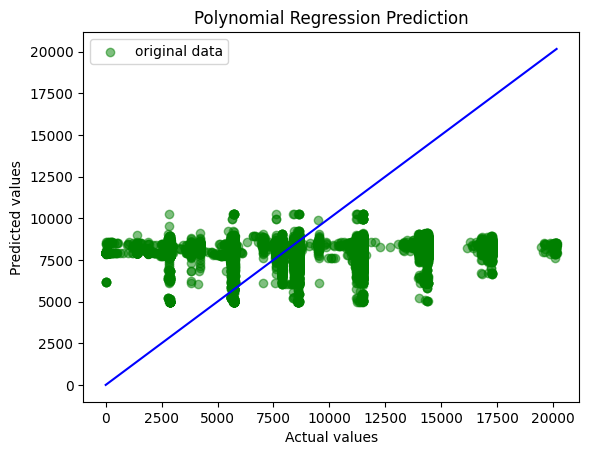

In [ ]:
# Visualization
plt.scatter(y_test, y_pred_poly, color='green', alpha=0.5, label='original data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue')
plt.title('Polynomial Regression Prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()
plt.show()

**Sigmoid Kernel**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Build SVR model (Sigmoid kernel)
svr_sigmoid= SVR(kernel='sigmoid')
svr_sigmoid.fit(X_train_sub, y_train)
# Predictions
y_pred_sigmoid= svr_sigmoid.predict(X_test_sub)
# Evaluation
rmse_sigmoid = np.sqrt(mean_squared_error(y_test,  y_pred_sigmoid))
mae_sigmoid= mean_absolute_error(y_test, y_pred_sigmoid)
r2_sigmoid= r2_score(y_test, y_pred_sigmoid)

print("**sigmoid kernel result**")
print(f"RMSE= {rmse_sigmoid: .4f}")
print(f"MAE= {mae_sigmoid: .4f}")
print(f"R2= {r2_sigmoid: .4f}")

**sigmoid kernel result**
RMSE=  4116.1151
MAE=  3442.2802
R2=  0.0009


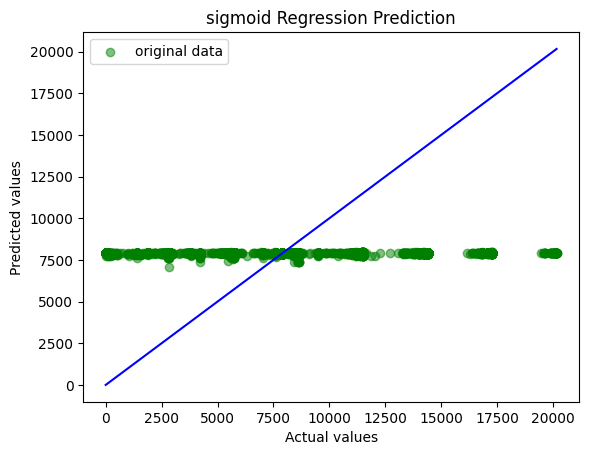

In [ ]:
# Visualization
plt.scatter(y_test, y_pred_sigmoid, color='green', alpha=0.5, label='original data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue')
plt.title('sigmoid Regression Prediction')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.legend()
plt.show()

*Random* forest

In [ ]:


# random forest regressor

df_subset = df[['Flow', 'Occupancy', 'Speed']].copy()

# Convert text values to numeric
df_subset['Speed'] = pd.to_numeric(df_subset['Speed'], errors='coerce')

# Remove missing values
df_subset = df_subset.dropna()

def run_random_forest_regressor(X, y):

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Create the model
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    # Train the model on the training data
    model.fit(X_train, y_train)

    # Predict values on the test data
    y_pred = model.predict(X_test)

    # Evaluation metrics between actual and predicted values
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Calculate feature importance
    fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

    # Print the top important features
    print("\nTop Feature Importance:")
    print(fi.head(10))

    # Return the model and results
    return model, {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "feature_importance": fi
    }, y_test, y_pred


In [ ]:


# Prepare the data
X_rf = df_subset[['Flow', 'Occupancy']].copy()
y_rf = df_subset['Speed'].copy()

# Run the Random Forest
rf_model, rf_results, y_test, y_pred = run_random_forest_regressor(X_rf, y_rf)

# Print evaluation results
print(f"MAE : {rf_results['mae']:.3f}")
print(f"RMSE: {rf_results['rmse']:.3f}")
print(f"R^2 : {rf_results['r2']:.3f}")

# Print feature importance
print("\n Top Feature Importance:")
print(rf_results['feature_importance'].head(10))




Top Feature Importance:
Occupancy    0.698672
Flow         0.301328
dtype: float64
MAE : 15.199
RMSE: 27.412
R^2 : 0.648

 Top Feature Importance:
Occupancy    0.698672
Flow         0.301328
dtype: float64


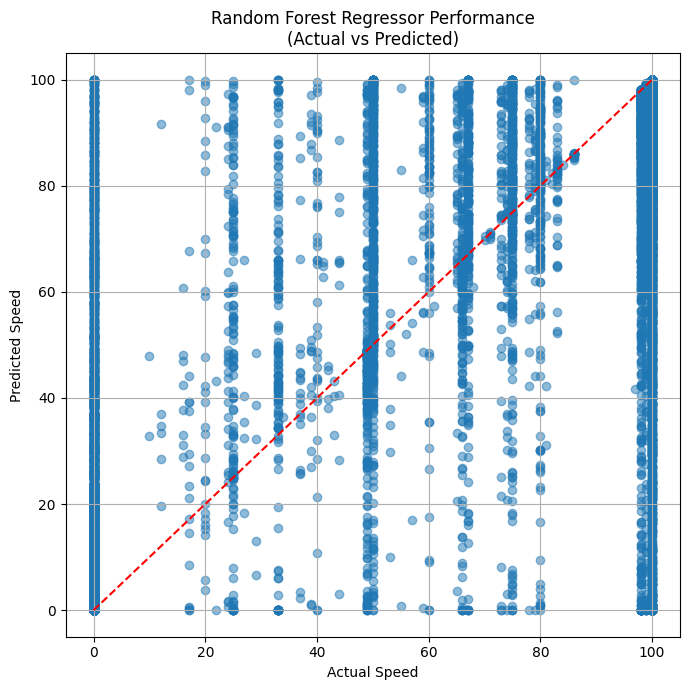

In [ ]:
#Model Performance - Random Forest
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Speed")
plt.ylabel("Predicted Speed")
plt.title("Random Forest Regressor Performance\n(Actual vs Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# GridSearchCV

# run Random Forest with GridSearchCV
def run_rf_with_gridsearch(X, y, cv_splits=5, random_state=42):

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # Base Random Forest model without tuned hyperparameters
    base = RandomForestRegressor(random_state=random_state, n_jobs=-1)

    # Hyperparameter grid
    param_grid = {
        "n_estimators": [50, 100],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt"]
    }

    # Prepare K-Fold cross validation
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

    # Set up GridSearchCV
    gs = GridSearchCV(
        estimator=base,
        param_grid=param_grid,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        refit="r2",
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    # Fit GridSearchCV (evaluate all combinations)
    gs.fit(X_train, y_train)
    # Extract the best model
    best_model = gs.best_estimator_

    # Predictions on the test set
    y_pred = best_model.predict(X_test)

    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Feature importance
    fi = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

    # Print basic results
    print("Best CV params:", gs.best_params_)
    print(f"Test RMSE: {rmse:.3f}")
    print(f"Test MAE : {mae:.3f}")
    print(f"Test R^2 : {r2:.3f}")
    print("\nTop Feature Importance:")
    print(fi.head(10))

    # Cross Validation results
    results = pd.DataFrame(gs.cv_results_).sort_values("rank_test_r2")

    # Convert RMSE & MAE to positive
    if "mean_test_rmse" in results.columns:
        results["mean_test_rmse"] = -results["mean_test_rmse"]

    if "mean_test_mae" in results.columns:
        results["mean_test_mae"] = -results["mean_test_mae"]

    return best_model, {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "best_params": gs.best_params_,
        "cv_results": results[[
            "params",
            "mean_test_r2",
            "mean_test_rmse",
            "mean_test_mae",
            "rank_test_r2"
        ]],
        "feature_importance": fi
    }


In [ ]:


df_subset = df[['Flow', 'Occupancy', 'Speed']].copy()

# Convert Speed column
df_subset.loc[:, 'Speed'] = pd.to_numeric(df_subset['Speed'], errors='coerce').astype(float)

# Variables used for prediction
X_rf = df_subset[['Flow', 'Occupancy']]

# Target variable to be predicted
y_rf = df_subset['Speed']

# Call the method using a sample of 500 rows
best_model, out = run_rf_with_gridsearch(
    X_rf.sample(500, random_state=42),
    y_rf.sample(500, random_state=42)
)

# Print the best hyperparameters found
print("\nBest Parameters:", out['best_params'])

# Print evaluation (added MAE)
print("RMSE:", round(out['rmse'], 3))
print("MAE :", round(out['mae'], 3))
print("R^2 :", round(out['r2'], 3))

# Print top features
print("\nTop Features:\n", out['feature_importance'].head(10))

# Display the first 10 results
out['cv_results'].head(10)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best CV params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Test RMSE: 42.617
Test MAE : 37.483
Test R^2 : 0.161

Top Feature Importance:
Occupancy    0.665288
Flow         0.334712
dtype: float64

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
RMSE: 42.617
MAE : 37.483
R^2 : 0.161

Top Features:
 Occupancy    0.665288
Flow         0.334712
dtype: float64


,params,mean_test_r2,mean_test_rmse,mean_test_mae,rank_test_r2
9,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.203141,41.977744,36.159762,1
13,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.202662,42.001666,36.325034,2
15,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.198067,42.120880,36.571298,3
21,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.195331,42.192730,34.382664,4
5,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.194391,42.216601,34.346063,5
23,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.192575,42.262811,34.520133,6
8,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.192004,42.265889,36.077664,7
7,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.191424,42.291993,34.502510,8
11,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.190881,42.306873,36.641744,9
12,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.187657,42.395465,36.585275,10
